# Clasificación de letras escritas a mano con redes neuronales

En este cuaderno vas a entrenar un modelo para clasificar imágenes de letras escritas a mano. Vamos a trabajar con EMNIST Letters, una extensión de MNIST orientada a caracteres alfabéticos.

## Objetivos de aprendizaje

Al finalizar este cuaderno, vas a poder:

- cargar un dataset de imágenes desde TensorFlow Datasets;
- preprocesar imágenes y etiquetas;
- entrenar una red densa para clasificación multiclase;
- evaluar el rendimiento del modelo;
- interpretar predicciones y una matriz de confusión.

## Microglosario

- **Clase**: categoría que el modelo debe predecir. En este caso, una letra.
- **Etiqueta**: respuesta correcta asociada a una imagen.
- **Normalización**: transformación de los valores de píxeles para que queden en una escala más conveniente.
- **Softmax**: función que convierte la salida del modelo en probabilidades por clase.
- **Matriz de confusión**: tabla que muestra aciertos y errores por clase.

## 1. Preparar herramientas

La primera celda instala dependencias si trabajás en Colab. Si ya las tenés instaladas, podés omitir la línea de instalación.

In [10]:
# En Colab puede ser necesario instalar estas bibliotecas.
# Si trabajás en un entorno local ya preparado, podés comentar esta línea.
#!pip install -q opencv-python-headless seaborn

import math

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import confusion_matrix

print("Herramientas cargadas.")

Herramientas cargadas.


## 2. Cargar EMNIST Letters

EMNIST Letters contiene imágenes de letras escritas a mano. Cada imagen tiene una etiqueta que indica qué letra representa.

In [11]:
print("Descargando y cargando el dataset EMNIST Letters. La primera ejecución puede tardar unos minutos.")

datos, metadatos = tfds.load(
    "emnist/letters",
    as_supervised=True,
    with_info=True,
)

nombres_clases = []

for indice in range(1, 27):
    letra = chr(indice + ord("a") - 1)
    nombres_clases.append(letra)

cantidad_entrenamiento = metadatos.splits["train"].num_examples
cantidad_prueba = metadatos.splits["test"].num_examples

print("Cantidad de imágenes de entrenamiento:", cantidad_entrenamiento)
print("Cantidad de imágenes de prueba:", cantidad_prueba)
print("Clases:", nombres_clases)

Descargando y cargando el dataset EMNIST Letters. La primera ejecución puede tardar unos minutos.


c:\Users\usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [00:38<00:00, 32.54s/ url]

Extraction completed...: 100%|██████████| 4/4 [00:01<00:00,  3.64 file/s]


Dataset emnist downloaded and prepared to C:\Users\usuario\tensorflow_datasets\emnist\letters\3.1.0. Subsequent calls will reuse this data.
Cantidad de imágenes de entrenamiento: 88800
Cantidad de imágenes de prueba: 14800
Clases: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


**Consigna de lectura:** revisá cuántas clases hay. ¿Qué diferencia aparece respecto de un problema binario como gato/perro?

## 3. Preprocesar imágenes y etiquetas

Las imágenes vienen con valores de píxel entre 0 y 255. Para entrenar una red neuronal, las llevamos al rango de 0 a 1.

EMNIST Letters usa etiquetas de 1 a 26. Las restamos en 1 para que queden de 0 a 25, que es el formato esperado para indexar la lista de letras.

In [12]:
def preprocesar_imagen(imagen, etiqueta):
    # Convertimos la imagen a números decimales.
    imagen = tf.cast(imagen, tf.float32)

    # Normalizamos los píxeles al rango 0-1.
    imagen = imagen / 255.0

    # Ajustamos etiquetas de 1-26 a 0-25.
    etiqueta = etiqueta - 1

    return imagen, etiqueta


datos_entrenamiento = datos["train"]
datos_prueba = datos["test"]

datos_entrenamiento = datos_entrenamiento.map(preprocesar_imagen)
datos_prueba = datos_prueba.map(preprocesar_imagen)

datos_entrenamiento = datos_entrenamiento.cache()
datos_prueba = datos_prueba.cache()

print("Datos preprocesados.")

Datos preprocesados.


## 4. Visualizar un ejemplo

Antes de entrenar, conviene mirar una imagen y su etiqueta. Esto permite verificar que el preprocesamiento no rompió la estructura del dato.

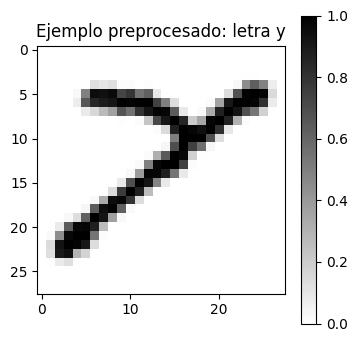

In [13]:
for imagen_ejemplo, etiqueta_ejemplo in datos_entrenamiento.take(1):
    imagen_a_mostrar = imagen_ejemplo.numpy()
    etiqueta_numerica = etiqueta_ejemplo.numpy()

letra = nombres_clases[etiqueta_numerica]

plt.figure(figsize=(4, 4))
plt.imshow(imagen_a_mostrar[:, :, 0], cmap=plt.cm.binary)
plt.title(f"Ejemplo preprocesado: letra {letra}")
plt.colorbar()
plt.grid(False)
plt.show()

**Consigna de lectura:** observá la orientación y la forma de la letra. ¿Se distingue con claridad?

## 5. Construir el modelo

Vamos a empezar con una red densa simple. La capa `Flatten` transforma la imagen de 28 x 28 píxeles en un vector. Luego, las capas densas aprenden patrones para clasificar la letra.

In [14]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(len(nombres_clases), activation="softmax"),
])

modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

modelo.summary()

c:\Users\usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,090 (219.10 KB)

 Trainable params: 56,090 (219.10 KB)

 Non-trainable params: 0 (0.00 B)

**Consigna de lectura:** identificá la capa de salida. ¿Por qué tiene 26 neuronas?

## 6. Preparar lotes de entrenamiento y validación

Agrupamos las imágenes en lotes. También dejamos el conjunto de prueba separado para evaluar si el modelo generaliza a datos no vistos durante el entrenamiento.

In [15]:
TAMANO_LOTE = 32

cantidad_entrenamiento = metadatos.splits["train"].num_examples

lotes_entrenamiento = datos_entrenamiento.shuffle(cantidad_entrenamiento)
lotes_entrenamiento = lotes_entrenamiento.batch(TAMANO_LOTE)
lotes_entrenamiento = lotes_entrenamiento.prefetch(tf.data.AUTOTUNE)

lotes_prueba = datos_prueba.batch(TAMANO_LOTE)
lotes_prueba = lotes_prueba.prefetch(tf.data.AUTOTUNE)

print("Tamaño de lote:", TAMANO_LOTE)

Tamaño de lote: 32


## 7. Entrenar el modelo

Durante el entrenamiento vamos a mirar tanto la precisión de entrenamiento como la precisión sobre datos de prueba. Esto ayuda a detectar si el modelo aprende patrones generales o si memoriza demasiado los ejemplos.

In [16]:
EPOCAS = 10

historial = modelo.fit(
    lotes_entrenamiento,
    epochs=EPOCAS,
    validation_data=lotes_prueba,
)

Epoch 1/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7375 - loss: 0.8837 - val_accuracy: 0.8109 - val_loss: 0.6285
Epoch 2/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8393 - loss: 0.5217 - val_accuracy: 0.8153 - val_loss: 0.5849
Epoch 3/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8629 - loss: 0.4366 - val_accuracy: 0.8486 - val_loss: 0.4715
Epoch 4/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8761 - loss: 0.3898 - val_accuracy: 0.8545 - val_loss: 0.4680
Epoch 5/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8845 - loss: 0.3605 - val_accuracy: 0.8551 - val_loss: 0.4639
Epoch 6/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8901 - loss: 0.3357 - val_accuracy: 0.8587 - val_loss: 0.4449
Epoch 7/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8961 - loss: 0.3149 - val_accuracy: 0.8624 - val_loss: 0.4315
Epoch 8/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9014 - loss: 0

## 8. Evaluar el modelo

La evaluación resume el rendimiento sobre imágenes que el modelo no usó para ajustar sus pesos.

In [17]:
perdida_prueba, precision_prueba = modelo.evaluate(lotes_prueba)

print(f"Pérdida en prueba: {perdida_prueba:.4f}")
print(f"Precisión en prueba: {precision_prueba:.4f}")
print(f"Precisión equivalente: {precision_prueba * 100:.2f}%")

463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8688 - loss: 0.4309
Pérdida en prueba: 0.4309
Precisión en prueba: 0.8688
Precisión equivalente: 86.88%


**Consigna de lectura:** compará la precisión de prueba con la precisión de entrenamiento. ¿Hay señales de sobreajuste?

## 9. Visualizar curvas de aprendizaje

Las curvas permiten observar cómo evolucionaron la pérdida y la precisión en cada época.

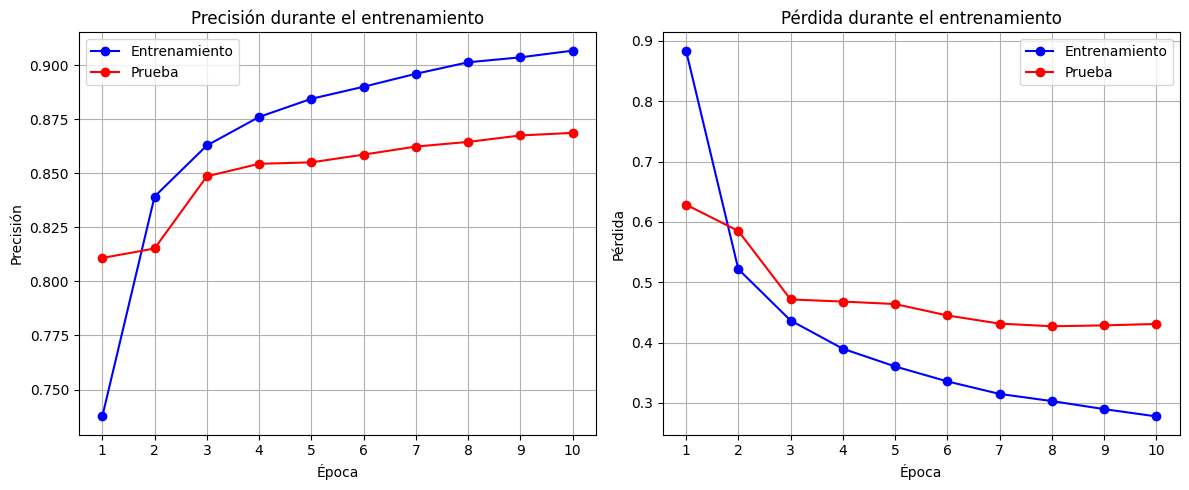

In [18]:
historial_metricas = historial.history
epocas = range(1, EPOCAS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epocas, historial_metricas["accuracy"], "bo-", label="Entrenamiento")
plt.plot(epocas, historial_metricas["val_accuracy"], "ro-", label="Prueba")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.xticks(epocas)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epocas, historial_metricas["loss"], "bo-", label="Entrenamiento")
plt.plot(epocas, historial_metricas["val_loss"], "ro-", label="Prueba")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.xticks(epocas)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Consigna de lectura:** si la precisión de entrenamiento sube y la de prueba se estanca o baja, el modelo puede estar sobreajustando.

## 10. Visualizar predicciones

Ahora inspeccionamos ejemplos concretos. El color azul indica predicción correcta y el color rojo indica predicción incorrecta.

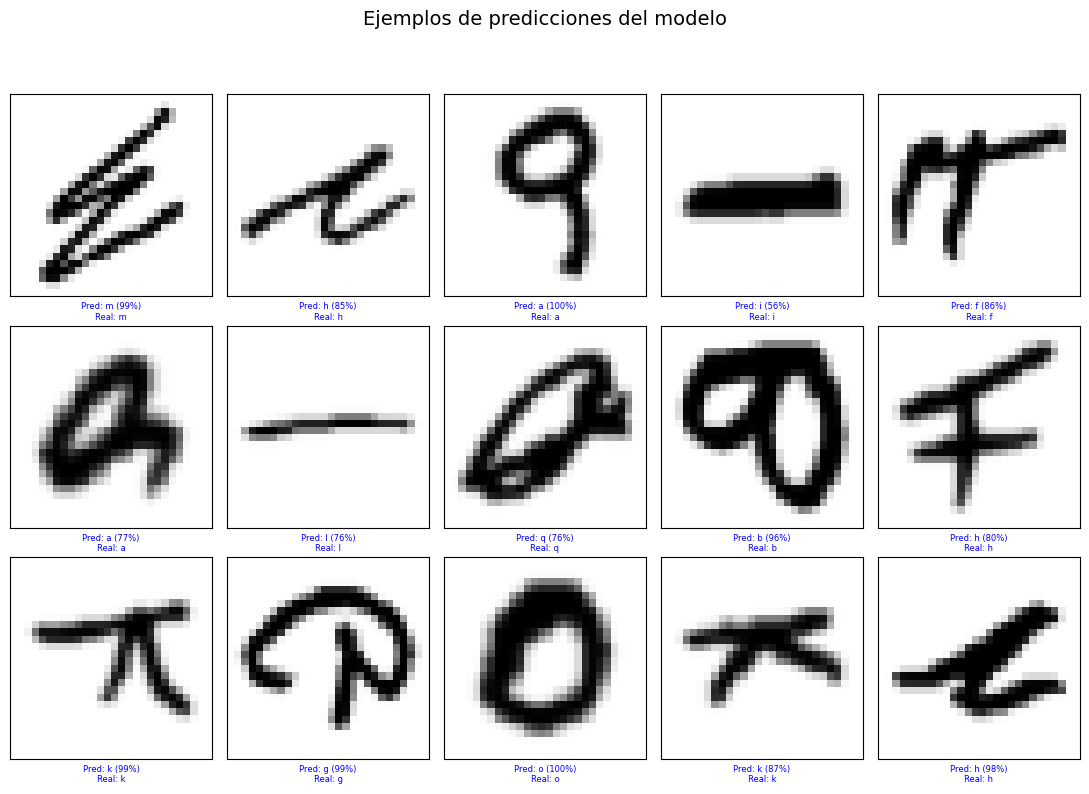

In [23]:
for imagenes_lote_prueba, etiquetas_lote_prueba in lotes_prueba.take(1):
    imagenes_a_predecir = imagenes_lote_prueba.numpy()
    etiquetas_reales = etiquetas_lote_prueba.numpy()
    probabilidades_predichas = modelo.predict(imagenes_a_predecir, verbose=0)
    break


def graficar_prediccion(indice, probabilidades, etiquetas_verdaderas, imagenes):
    probabilidades_imagen = probabilidades[indice]
    etiqueta_verdadera = etiquetas_verdaderas[indice]
    imagen = imagenes[indice]

    indice_predicho = np.argmax(probabilidades_imagen)
    letra_predicha = nombres_clases[indice_predicho]
    letra_real = nombres_clases[etiqueta_verdadera]
    confianza = np.max(probabilidades_imagen)

    if indice_predicho == etiqueta_verdadera:
        color = "blue"
    else:
        color = "red"

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(imagen[:, :, 0], cmap=plt.cm.binary)
    plt.xlabel(
    f"Pred: {letra_predicha} ({confianza * 100:.0f}%)\nReal: {letra_real}",
    color=color,
    fontsize=6,
)


filas = 3
columnas = 5
cantidad_imagenes = filas * columnas

plt.figure(figsize=(2 * columnas + 1, 2 * filas + 2))
plt.suptitle("Ejemplos de predicciones del modelo", fontsize=14)

for indice in range(cantidad_imagenes):
    plt.subplot(filas, columnas, indice + 1)
    graficar_prediccion(indice, probabilidades_predichas, etiquetas_reales, imagenes_a_predecir)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Consigna de lectura:** buscá una predicción incorrecta. ¿La letra real se parece visualmente a la letra predicha?

## 11. Analizar errores con matriz de confusión

La matriz de confusión permite ver qué clases se confunden entre sí. La diagonal principal representa aciertos. Los valores fuera de la diagonal representan errores.

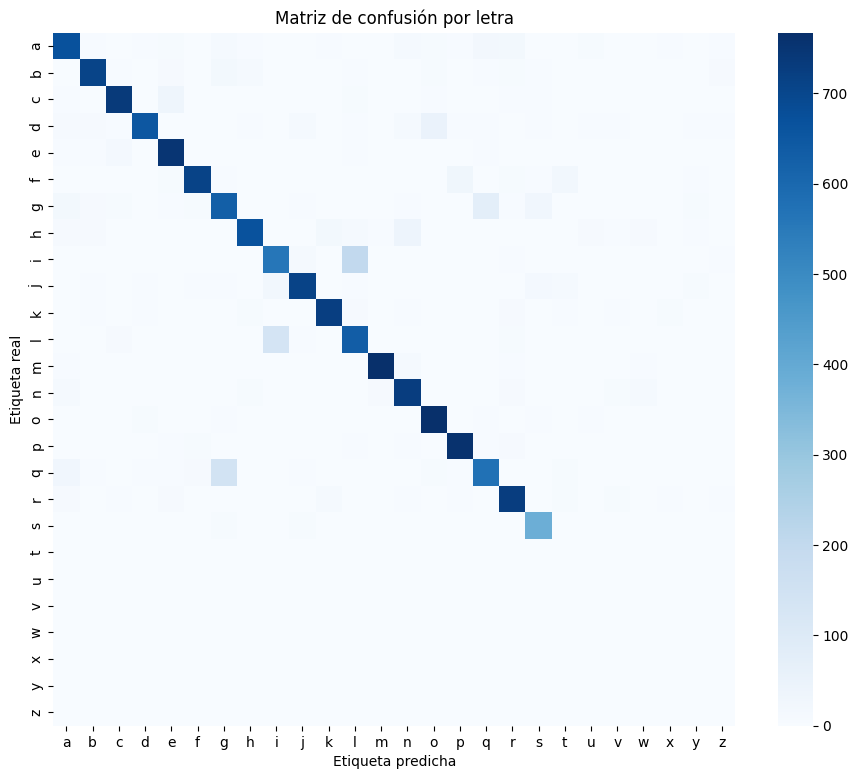

In [24]:
indices_predichos_todos = []
etiquetas_reales_todas = []

for imagenes_lote, etiquetas_lote in lotes_prueba:
    probabilidades_lote = modelo.predict(imagenes_lote, verbose=0)
    indices_predichos_lote = np.argmax(probabilidades_lote, axis=1)

    indices_predichos_todos.extend(indices_predichos_lote)
    etiquetas_reales_todas.extend(etiquetas_lote.numpy())

indices_predichos_todos = np.array(indices_predichos_todos)
etiquetas_reales_todas = np.array(etiquetas_reales_todas)

matriz_confusion = confusion_matrix(etiquetas_reales_todas, indices_predichos_todos)

plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_confusion,
    annot=False,
    cmap="Blues",
    fmt="d",
    xticklabels=nombres_clases,
    yticklabels=nombres_clases,
)
plt.xlabel("Etiqueta predicha")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión por letra")
plt.show()

**Consigna de lectura:** identificá dos letras que el modelo confunda con frecuencia. ¿Qué rasgos visuales comparten?

## Cierre

Este cuaderno mostró una clasificación multiclase con imágenes simples. La red densa pudo aprender patrones generales, pero todavía no aprovecha de manera explícita la estructura espacial de la imagen.

El próximo paso será usar redes neuronales convolucionales, que están diseñadas para trabajar mejor con píxeles, bordes, formas y patrones locales.